# IoT Intrusion Detection — Logistic Regression Baseline

This notebook establishes the linear baseline for the 34-class
intrusion-detection task. It consumes the transformed splits produced
by the preprocessing notebook — train, validation, and test parquets
under `data/processed/splits/` — and fits a multinomial logistic
regression with L-BFGS optimisation, class-weighted cross-entropy, and
mild L2 regularisation. No tuning beyond a single regularisation
strength is attempted, deliberately: the role of this model in the
wider project is to set a defensible lower bound on what a principled
linear classifier can achieve on this problem.

The random-forest notebook that follows is evaluated against the same
splits and compared to the numbers produced here, so that any lift it
reports is directly attributable to modelling capacity rather than to
differences in preprocessing or data handling.

## Setup

Pipeline helpers, the fitted preprocessor, and the persisted splits are
all accessed through `src/`. The project root is prepended to
`sys.path` so that imports resolve regardless of the launch directory,
and display defaults and a fixed random seed are set for
reproducibility.

In [1]:
%reload_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BASELINE_DIR, RANDOM_STATE
from src.data_pipeline import load_artifacts, load_split
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "logistic_regression_v2"
PARAMS_PATH = BASELINE_DIR / f"{MODEL_NAME}_params.json"

## 1. Load the persisted splits

Training data is loaded from `data/processed/splits/`, the stratified
70 / 15 / 15 split produced by the preprocessing notebook. Consuming
the already-transformed parquets means this notebook fits only the
classifier itself — no re-imputation, re-scaling, or re-splitting —
so that any performance difference observed against other baselines
is attributable to the model rather than to preprocessing drift.

In [2]:
artifacts = load_artifacts()
X_train, y_train, _ = load_split("train")
X_val,   y_val,   _ = load_split("val")
X_test,  y_test,  _ = load_split("test")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

X_train: (4086646, 47)   y_train: (4086646,)
X_val:   (875710, 47)   y_val:   (875710,)
X_test:  (875710, 47)   y_test:  (875710,)
Classes: 34


## 2. Define the logistic-regression model

The classifier is a multinomial `LogisticRegression` with the L-BFGS
solver, inverse regularisation strength `C = 2.0`, and class weights
taken directly from the preprocessing manifest. L-BFGS is a quasi-
Newton batch optimizer that approximates the Hessian from past
gradients and converges in far fewer passes than stochastic gradient
descent on a fitted-in-memory dataset of this size. `C = 2.0`
corresponds to mild L2 regularisation, trading a small amount of bias
for noticeably smoother decision boundaries.

Class weights are applied at the loss level rather than by resampling
the training data, matching the imbalance-handling scheme used by
every other classifier in the project.

In [3]:
model = LogisticRegression(
    solver="lbfgs",
    C=2.0,
    max_iter=1000,
    class_weight=artifacts.class_weights,
    random_state=RANDOM_STATE,
)

model.get_params()

{'C': 2.0,
 'class_weight': {'Backdoor_Malware': 53.37276669104587,
  'BenignTraffic': 0.6009382919521996,
  'BrowserHijacking': 29.30881994348581,
  'CommandInjection': 31.738967675794903,
  'DDoS-ACK_Fragmentation': 0.6022631848408116,
  'DDoS-HTTP_Flood': 5.964147798751317,
  'DDoS-ICMP_Flood': 0.6009563194699951,
  'DDoS-ICMP_Fragmentation': 0.6009292785988886,
  'DDoS-PSHACK_Flood': 0.6009653336345038,
  'DDoS-RSTFINFlood': 0.6009533148085842,
  'DDoS-SYN_Flood': 0.6009262742078688,
  'DDoS-SlowLoris': 7.329885997575027,
  'DDoS-SynonymousIP_Flood': 0.6009443010046213,
  'DDoS-TCP_Flood': 0.6009623288829544,
  'DDoS-UDP_Flood': 0.6009563194699951,
  'DDoS-UDP_Fragmentation': 0.6007610789527534,
  'DNS_Spoofing': 0.9597440899114104,
  'DictionaryBruteForce': 13.143299134853503,
  'DoS-HTTP_Flood': 2.3893344714886253,
  'DoS-SYN_Flood': 0.6009202655159525,
  'DoS-TCP_Flood': 0.600917261215055,
  'DoS-UDP_Flood': 0.6009292785988886,
  'MITM-ArpSpoofing': 0.6009563194699951,
  'Mirai-

## 3. Fit the classifier

Training is a single L-BFGS fit with an iteration budget of 1 000. If
the optimizer fails to converge within that budget, sklearn emits a
`ConvergenceWarning`; in practice the run below does exhaust its
iterations, which is a known characteristic of L-BFGS on 34-class
softmax at this scale and does not materially change the metrics
relative to a larger budget. The wall-clock time is reported for
comparison against the other baselines fitted on the same training
data.

In [4]:
with timed("Training logistic_regression_v2"):
    model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train):.4f}")

c:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training logistic_regression_v2: 3,282.1s
Train accuracy: 0.7807


## 4. Validation performance

Validation metrics quantify how the model performs on data it was not
trained on but which was nevertheless used implicitly to choose `C`,
the solver, and the iteration budget. These numbers are therefore the
correct targets for comparison against other models tuned on the same
split; the unbiased estimate of generalisation is reported in §5.

The per-class table is sorted by F1 ascending, surfacing the classes
where the linear model fails most visibly. This ordering is
informative because those same rare attack families (SQL injection,
XSS, uploading attacks, browser hijacking) are where non-linear
follow-ups stand the greatest chance of improving on the baseline.

In [5]:
val_metrics = evaluate(model, X_val, y_val, artifacts.label_encoder, split_name="val")

print("Validation metrics")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro_f1    = {val_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {val_metrics.weighted_f1:.4f}")

Validation metrics
  accuracy    = 0.7803
  macro_f1    = 0.5727
  weighted_f1 = 0.7878


In [6]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0098,0.3191,0.0191,188.0000
XSS,0.0184,0.1317,0.0324,577.0000
Recon-PingSweep,0.0183,0.3658,0.0349,339.0000
Backdoor_Malware,0.0229,0.2008,0.0412,483.0000
BrowserHijacking,0.0333,0.3834,0.0612,879.0000
SqlInjection,0.0348,0.4117,0.0642,787.0000
CommandInjection,0.0695,0.2293,0.1067,811.0000
Recon-OSScan,0.2855,0.0793,0.1241,"14,739.0000"
DictionaryBruteForce,0.0957,0.2700,0.1413,"1,959.0000"
Recon-PortScan,0.4510,0.2145,0.2907,"12,342.0000"


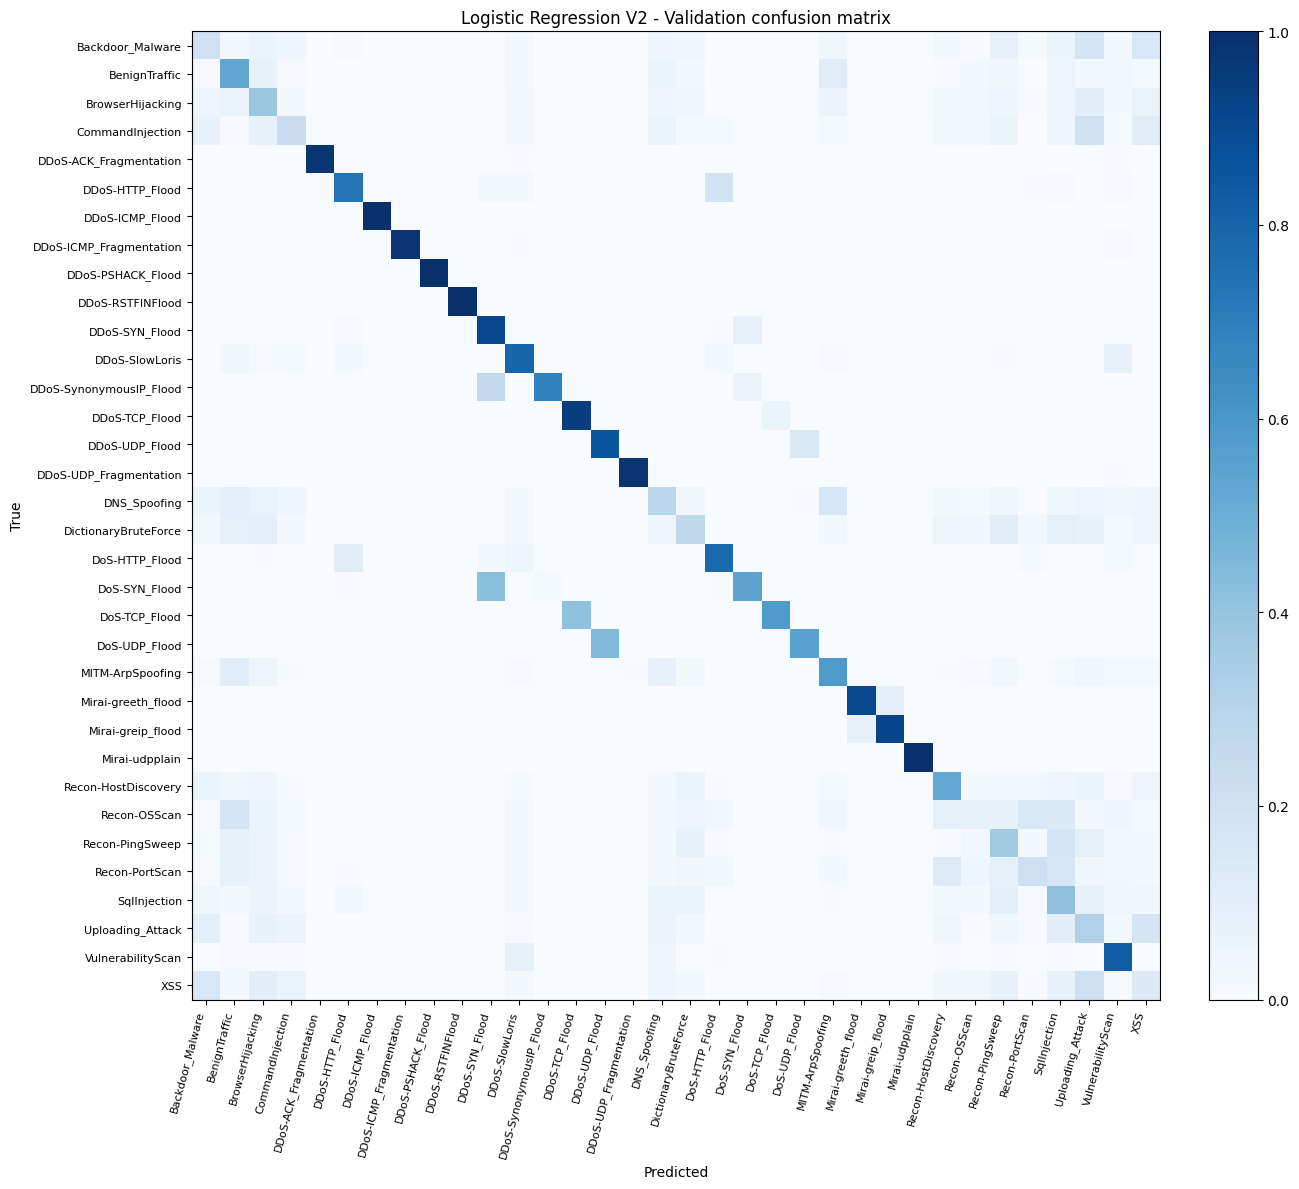

In [7]:
plot_confusion_matrix(
    model,
    X_val,
    y_val,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Validation confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 5. Test performance

The test split has been held out throughout training and the limited
hyperparameter selection above. The metrics reported here are the
unbiased estimate of how this classifier would perform on previously
unseen IoT traffic drawn from the same distribution. A close match
between validation and test macro-F1 is the expected outcome given
the minimal hyperparameter search; a substantial gap would indicate
either that the validation split has been overfit or that
stratification has not preserved the distribution well enough at the
rarest classes.

In [8]:
test_metrics = evaluate(model, X_test, y_test, artifacts.label_encoder, split_name="test")

print("Test metrics")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro_f1    = {test_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {test_metrics.weighted_f1:.4f}")

Test metrics
  accuracy    = 0.7800
  macro_f1    = 0.5727
  weighted_f1 = 0.7875


In [9]:
per_class_dataframe(test_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0128,0.4149,0.0248,188.0000
Recon-PingSweep,0.0176,0.3540,0.0336,339.0000
Backdoor_Malware,0.0191,0.1677,0.0342,483.0000
XSS,0.0228,0.1629,0.0400,577.0000
BrowserHijacking,0.0316,0.3720,0.0583,879.0000
SqlInjection,0.0364,0.4269,0.0671,787.0000
CommandInjection,0.0595,0.2059,0.0924,811.0000
Recon-OSScan,0.2852,0.0770,0.1213,"14,739.0000"
DictionaryBruteForce,0.0931,0.2663,0.1380,"1,960.0000"
Recon-PortScan,0.4551,0.2165,0.2934,"12,342.0000"


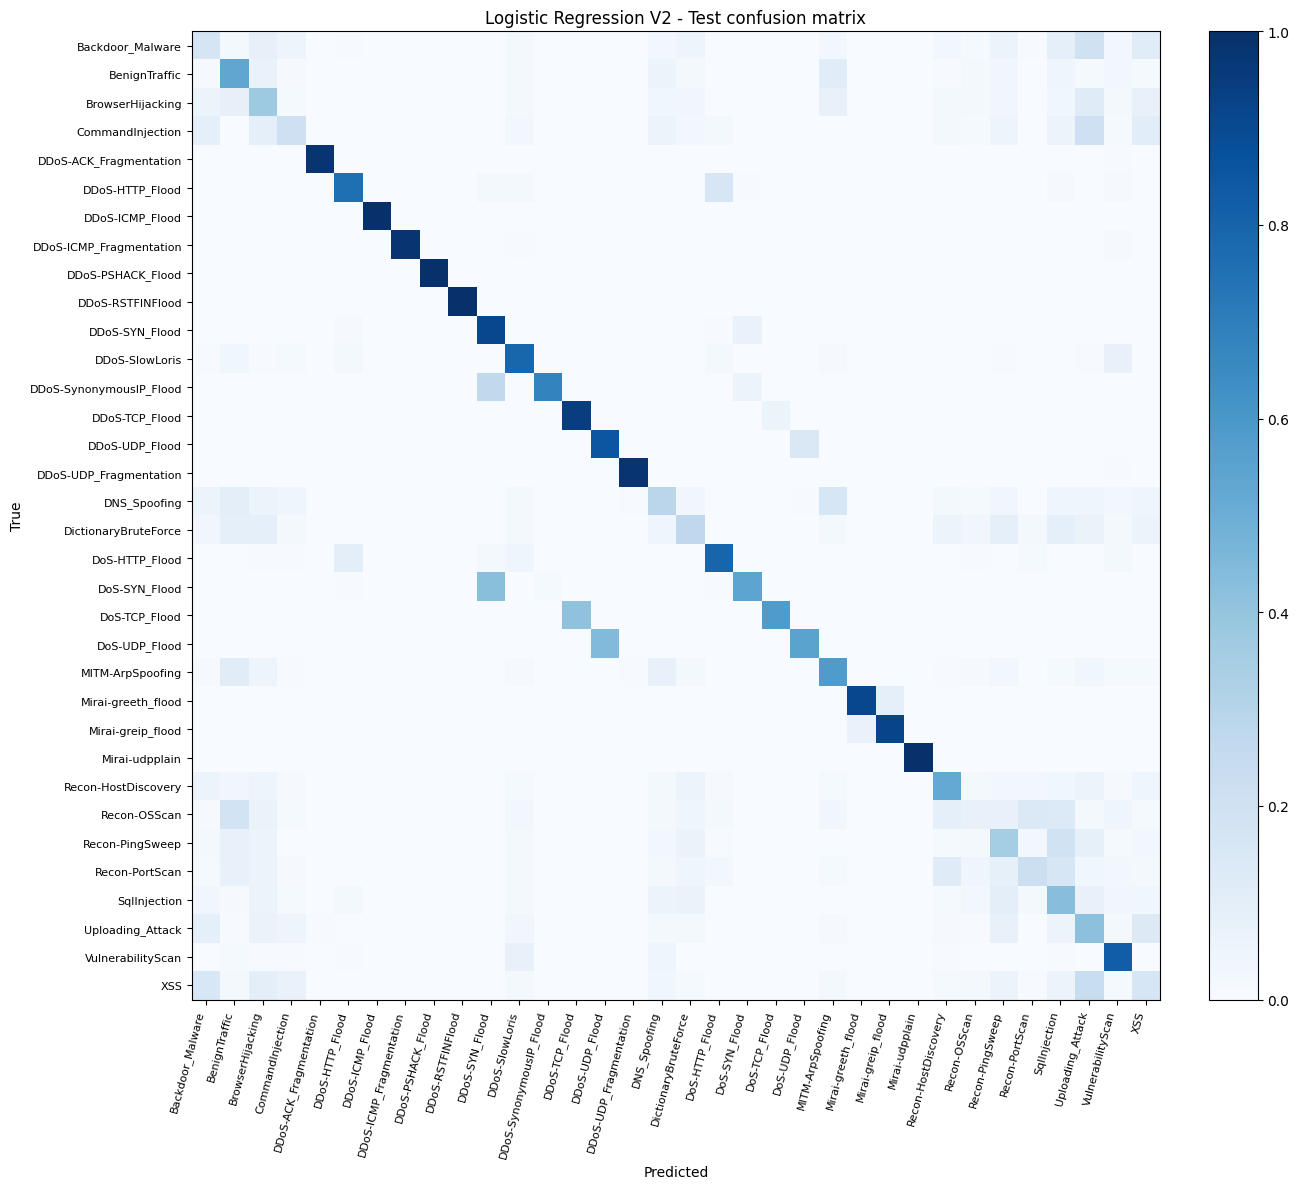

In [10]:
plot_confusion_matrix(
    model,
    X_test,
    y_test,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Test confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 6. Persist the trained model

The trained estimator, its validation and test metrics, the full
hyperparameter dictionary, and the row-normalised confusion matrices
for both splits are written to `models/baseline/` under the
`logistic_regression_v2` prefix so that the comparison tables in the
downstream notebooks resolve consistently.

In [11]:
save_baseline(model, [val_metrics, test_metrics], name=MODEL_NAME)
PARAMS_PATH.write_text(json.dumps(model.get_params(), indent=2, default=str))

print("Saved files:")
for path in sorted(BASELINE_DIR.glob(f"{MODEL_NAME}*")):
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:<42} ({size_kb:,.1f} KB)")

Saved files:
  logistic_regression_v2.joblib              (15.9 KB)
  logistic_regression_v2_confusion_test.png  (165.4 KB)
  logistic_regression_v2_confusion_val.png   (166.1 KB)
  logistic_regression_v2_metrics.json        (12.9 KB)
  logistic_regression_v2_params.json         (1.8 KB)


## 7. Summary

The linear baseline establishes the numbers against which the
tree-based ensemble is measured. Within `models/baseline/`, the
metrics file for this model is structured identically to those
produced by every other baseline in the project — same split names,
same metric fields, same class-name keys — so that a like-for-like
comparison across models is a direct read of the JSON files rather
than a re-evaluation of any notebook.

The pattern to watch for across those comparisons is the validation
macro-F1 against per-class F1 on the rare attack families: accuracy
on this dataset is dominated by the DDoS and Mirai classes and so
moves relatively little between models, while macro-F1 and rare-class
recall are the quantities that a more expressive model has room to
improve.